# Optimizing Human Connection in CallMeMaybe: Efficiency Diagnosis and Operational Improvement Strategies

# Optimizando la Conexión Humana en CallMeMaybe
## Diagnóstico de Eficiencia y Estrategias de Mejora Operativa

## Problema y objetivo:
###  El objetivo principal es identificar operadores ineficaces en el servicio de telefonía virtual CallMeMaybe, basándose en llamadas perdidas, tiempo de espera prolongado y bajo número de llamadas salientes. También realizaremos un análisis exploratorio de datos (EDA) y pruebas de hipótesis estadísticas.

## Paso 1:
## Carga de datos y EDA

In [ ]:
#Importamos la librería necesaria para cargar los datos y inspeccionarlos.

import pandas as pd
import numpy as np

clients = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/proyecto_final_telecom/telecom_clients.csv')
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/proyecto_final_telecom/telecom_dataset_new.csv')

# Visualizamos la informacion general de los Datasets.
print("Información de clients:")
display(clients.info())
print("\nInformación de data:")
display(data.info())

print("\n ---------------------------------------------------------------")

# Vizualizamos las primeras 5 filas
print("Primeras 5 filas de clients:")
display(clients.head())
print("\n ---------------------------------------------------------------")
print("Primeras 5 filas de data:")
display(data.head())

print("\n ---------------------------------------------------------------")

# Visualizamos 5 filas aleatorias
sample_clients = clients.sample(5)
sample_data = data.sample(5)

print("5 filas aleatorias de clients:")
display(sample_clients)
print("\n ---------------------------------------------------------------")
print("\n5 filas aleatorias de data:")
display(sample_data)

print("\n ---------------------------------------------------------------")

# Vizualizamos la forma de los Datasets
print("Forma de clients:", clients.shape)
print("\n ---------------------------------------------------------------")
print("Forma de data:", data.shape)



Información de clients:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   user_id      732 non-null    int64 
 1   tariff_plan  732 non-null    object
 2   date_start   732 non-null    object
dtypes: int64(1), object(2)
memory usage: 17.3+ KB


None


Información de data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              53902 non-null  int64  
 1   date                 53902 non-null  object 
 2   direction            53902 non-null  object 
 3   internal             53785 non-null  object 
 4   operator_id          45730 non-null  float64
 5   is_missed_call       53902 non-null  bool   
 6   calls_count          53902 non-null  int64  
 7   call_duration        53902 non-null  int64  
 8   total_call_duration  53902 non-null  int64  
dtypes: bool(1), float64(1), int64(4), object(3)
memory usage: 3.3+ MB


None


 ---------------------------------------------------------------
Primeras 5 filas de clients:


...


 ---------------------------------------------------------------
5 filas aleatorias de clients:


,user_id,tariff_plan,date_start
178,168024,C,2019-10-09
126,168473,C,2019-10-28
432,167318,C,2019-09-11
551,168309,B,2019-10-21
666,166377,B,2019-08-01



 ---------------------------------------------------------------

5 filas aleatorias de data:


,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
1641,166405,2019-11-21 00:00:00+03:00,out,False,939476.0,False,73,6407,7774
5804,166536,2019-10-07 00:00:00+03:00,out,True,925826.0,False,1,7,13
4827,166511,2019-10-17 00:00:00+03:00,out,False,891410.0,False,34,3561,3780
43468,167998,2019-10-25 00:00:00+03:00,in,False,NaN,True,1,0,15
25356,167125,2019-10-08 00:00:00+03:00,out,False,902782.0,True,45,0,1180



 ---------------------------------------------------------------
Forma de clients: (732, 3)

 ---------------------------------------------------------------
Forma de data: (53902, 9)


### Observaciones:
#### Convertiremos la columna "date_start" de clients a datetime, y la columna "date" de data a datetime. Gestionaremos los valores faltantes en las columnas "internal" y "operator_id" de data y calcula la columna "waiting_time" utilizando "total_call_duration" y "call_duration". A continuación, fusionaremos los DataFrames de clients y data en "user_id".

### Preprocesamiento y Combinación de Datos
#### Convertir las columnas de fecha a formato datetime, manejar los valores faltantes en 'internal' y 'operator_id', calcular la columna 'waiting_time' y combinar los dataframes.


In [ ]:
# Corregimos los tipos de datos de Fechas
clients['date_start'] = pd.to_datetime(clients['date_start'])
data['date'] = pd.to_datetime(data['date'])

# Manejo del operator_id no identificado, lo quitamos y convertimos.
data_unassigned = data[data['operator_id'].isna()].copy() #Hacemos una copia para guardar los no asignados como prevención
data_clean = data.dropna(subset=['operator_id']).copy() # Dejamos solo los operadores identificados para el analisis de eficiencia.
data_clean['operator_id'] = data_clean['operator_id'].astype(int) # Convertimos el operator_id a entero

# Unimos Clientes con planes usando left join para no perder llamadas si faltase informacion
df_merged = data_clean.merge(clients, on='user_id', how='left')

# Visualizamos la cantidad de registros originales vs los filtrados
print("Registros originales:", len(data))
print("Registros tras eliminar operator_id nulos:", len(df_merged))
print('------------------------------------------------ \n')

display(df_merged.head())
display(df_merged.info())

Registros originales: 53902
Registros tras eliminar operator_id nulos: 45730
------------------------------------------------ 



,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration,tariff_plan,date_start
0,166377,2019-08-05 00:00:00+03:00,out,True,880022,True,3,0,5,B,2019-08-01
1,166377,2019-08-05 00:00:00+03:00,out,True,880020,True,1,0,1,B,2019-08-01
2,166377,2019-08-05 00:00:00+03:00,out,True,880020,False,1,10,18,B,2019-08-01
3,166377,2019-08-05 00:00:00+03:00,out,False,880022,True,3,0,25,B,2019-08-01
4,166377,2019-08-05 00:00:00+03:00,out,False,880020,False,2,3,29,B,2019-08-01


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45730 entries, 0 to 45729
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype                    
---  ------               --------------  -----                    
 0   user_id              45730 non-null  int64                    
 1   date                 45730 non-null  datetime64[ns, UTC+03:00]
 2   direction            45730 non-null  object                   
 3   internal             45670 non-null  object                   
 4   operator_id          45730 non-null  int64                    
 5   is_missed_call       45730 non-null  bool                     
 6   calls_count          45730 non-null  int64                    
 7   call_duration        45730 non-null  int64                    
 8   total_call_duration  45730 non-null  int64                    
 9   tariff_plan          45730 non-null  object                   
 10  date_start           45730 non-null  datetime64[ns]           
dtypes:

None

In [ ]:
# Calculamos el tiempo de espera, waiting_time
# data['internal'] = data['internal'].fillna(False)
df_merged['waiting_time'] = df_merged['total_call_duration'] - df_merged['call_duration']

# Realizamos ahora los ajustes y vemos si la llamada sale o entra
# El waiting time no aplicaria si es 0
df_merged.loc[df_merged['direction'] == 'out', 'waiting_time'] = 0
df_merged['waiting_time'] = df_merged['waiting_time'].clip(lower=0)

# Agregamos las columnas auxiliares.
df_merged['is_incoming'] = (df_merged['direction'] == 'in').astype(int)
df_merged['is_outgoing'] = (df_merged['direction'] == 'out').astype(int)

# Ahora definimos si la llamada es entrante o si esta marcada como perdida
# Para ver si es perdida o missed usamos la duracion si =0 en las entrantes
df_merged['is_missed'] = ((df_merged['is_incoming'] == 1) & (df_merged['call_duration'] ==0)).astype(int)

# Calculamos el tiempo de espera para las entrantes
df_merged['waiting_time_incoming'] = df_merged['waiting_time'] * df_merged['is_incoming']

# Calculamos el tiempo de espera para las salientes
df_merged['waiting_time_outgoing'] = df_merged['waiting_time'] * df_merged['is_outgoing']



### Observaciones:
#### Como se identificaron un número grande de registros con operator_id nulo, estos se han separado en un dataframe data_unassigned para no sesgar el análisis de rendimiento individual de los operadores por ese factor.

#### El dataset limpio data_clean contiene ahora únicamente registros con operadores identificados, lo que nos garantiza que las métricas de eficiencia que calculemos sean correctamente de personas reales.

#### Luego fusiónamos con la tabla clients, permitiendonos asociar cada llamada con el plan tarifario del cliente, un factor importante para nuestro análisis segmentado.

## Análisis Exploratorio de Datos (EDA)

#### Realizaremos un EDA exhaustivo para comprender la estructura de los datos en el nuevo Dataframe "df_merged", incluyendo estadísticas descriptivas, identificación de valores atípicos, análisis de la distribución de variables clave y visualización de tendencias que puedan influir en la ineficacia de los operadores.


In [ ]:
# Primero veremos las estadísticas descriptivas  para las columnas numericas.
# Así podremos ver algunas tendencias de interés.

print("Estadísticas descriptivas de las columnas numéricas de df_merged:")
display(df_merged.describe())

Estadísticas descriptivas de las columnas numéricas de df_merged:


,user_id,operator_id,calls_count,call_duration,total_call_duration,date_start,waiting_time,is_incoming,is_outgoing,is_missed,waiting_time_incoming,waiting_time_outgoing
count,45730.000000,45730.000000,45730.000000,45730.000000,45730.000000,45730,45730.000000,45730.000000,45730.000000,45730.000000,45730.000000,45730.0
mean,167302.220315,916535.993002,16.904417,1009.765121,1322.141789,2019-09-09 07:56:59.881915392,29.797157,0.306429,0.693571,0.009687,29.797157,0.0
min,166377.000000,879896.000000,1.000000,0.000000,0.000000,2019-08-01 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
25%,166782.000000,900788.000000,1.000000,0.000000,68.000000,2019-08-19 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
50%,167175.000000,913938.000000,4.000000,106.000000,290.500000,2019-09-05 00:00:00,0.000000,0.000000,1.000000,0.000000,0.000000,0.0
75%,167827.000000,937708.000000,14.000000,772.000000,1110.000000,2019-10-02 00:00:00,13.000000,1.000000,1.000000,0.000000,13.000000,0.0
max,168606.000000,973286.000000,4817.000000,144395.000000,166155.000000,2019-10-31 00:00:00,3998.000000,1.000000,1.000000,1.000000,3998.000000,0.0
std,600.731240,21254.123136,59.045234,4014.600085,4732.427880,NaN,111.637815,0.461015,0.461015,0.097947,111.637815,0.0


### Observaciones:
#### Podemos ver que hay una alta variabilidad y un sesgo a la derecha en las distribuciones de calls_count, call_duration, total_call_duration y waiting_time. Esto quiere decir que la mayoría de los valores se concentran en la parte inferior de la escala, pero existen algunos eventos extremos que tiran la media hacia arriba. Esto será importante para el análisis de operadores ineficaces, porque los valores atípicos pueden indicar rendimientos que requerirán una exploración más profunda.

#### Estas observaciones iniciales sugieren que necesitaremos visualizar las distribuciones de estas variables para entender mejor la magnitud y el impacto de estos valores extremos en el rendimiento de los operadores.


### Visualizar las tendencias importantes que puedan influir en la ineficacia de los operadores.

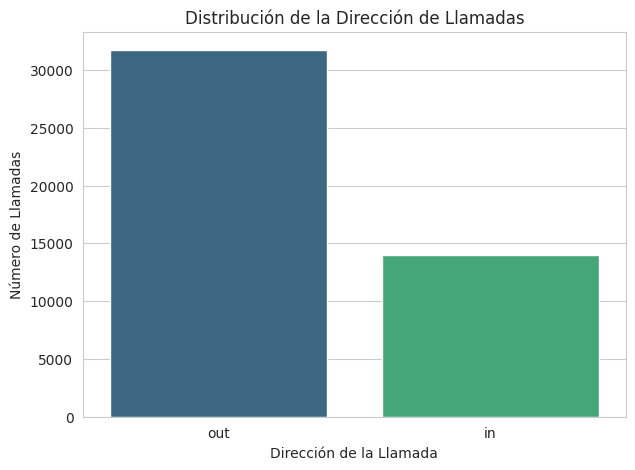

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configure plot styles for better readability
sns.set_style("whitegrid")

# 1. Gráfico de conteo para 'direction'
plt.figure(figsize=(7, 5))
sns.countplot(data=df_merged, x='direction', hue='direction', palette='viridis', legend=False)
plt.title('Distribución de la Dirección de Llamadas')
plt.xlabel('Dirección de la Llamada')
plt.ylabel('Número de Llamadas')
plt.show()


### Observaciones del gráfico 'Distribución de la Dirección de Llamadas':

#### Este gráfico revela que hay un número mucho mayor de llamadas salientes que de llamadas entrantes. Esta distribución sugiere que la empresa podría estar adoptando una estrategia proactiva, enfocada en la iniciar el contacto con los clientes, ya sea para ventas, seguimiento o atención. Esto nos sirve para entender el modelo operativo de la empresa.

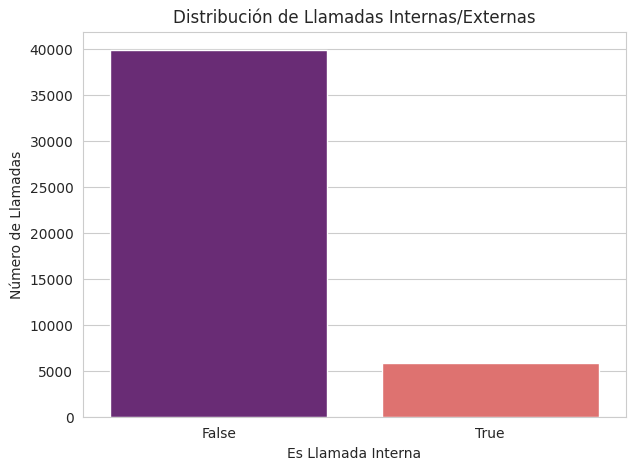

In [ ]:
# 2. Gráfico de conteo para 'internal'
plt.figure(figsize=(7, 5))
sns.countplot(data=df_merged, x='internal', hue='internal', palette='magma', legend=False)
plt.title('Distribución de Llamadas Internas/Externas')
plt.xlabel('Es Llamada Interna')
plt.ylabel('Número de Llamadas')
plt.show()



### Observaciones del gráfico 'Distribución de Llamadas Internas/Externas':

#### Este gráfico muestra una clara dominación de llamadas externas sobre las internas. Esto puede indicar que la mayoría de la actividad de comunicación en la empresa está orientada hacia el exterior, es decir, interactuando con clientes o otras entidades externas. Las llamadas internas se ve que son mucho menores en volumen. Esto refuerza la idea que tenemos de que la empresa tiene un enfoque principal en la comunicación externa, ya sea de servicio al cliente, ventas o soporte.

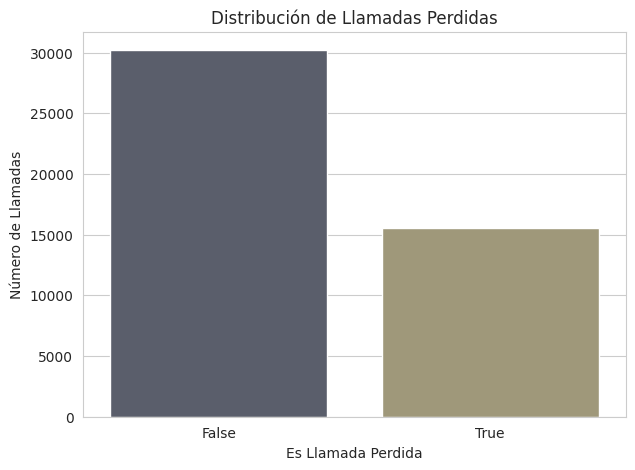

In [ ]:
# 3. Gráfico de conteo para 'is_missed_call'
plt.figure(figsize=(7, 5))
sns.countplot(data=df_merged, x='is_missed_call', hue='is_missed_call', palette='cividis', legend=False)
plt.title('Distribución de Llamadas Perdidas')
plt.xlabel('Es Llamada Perdida')
plt.ylabel('Número de Llamadas')
plt.show()



### Observaciones del gráfico 'Distribución de Llamadas Perdidas':

#### El gráfico muestra la proporción de llamadas que son marcadas como perdidas "True" frente a las que no lo son "False". Se puede ver que la gran mayoría de las llamadas no son perdidas, lo que es un indicador positivo de la eficiencia operativa general. Sin embargo, el que hayan llamadas perdidas, señala un área para mejorar la atención al cliente. Sería importante analizar si estas llamadas perdidas se relacionan con periodos específicos, operadores o planes tarifarios.

### Histogramas


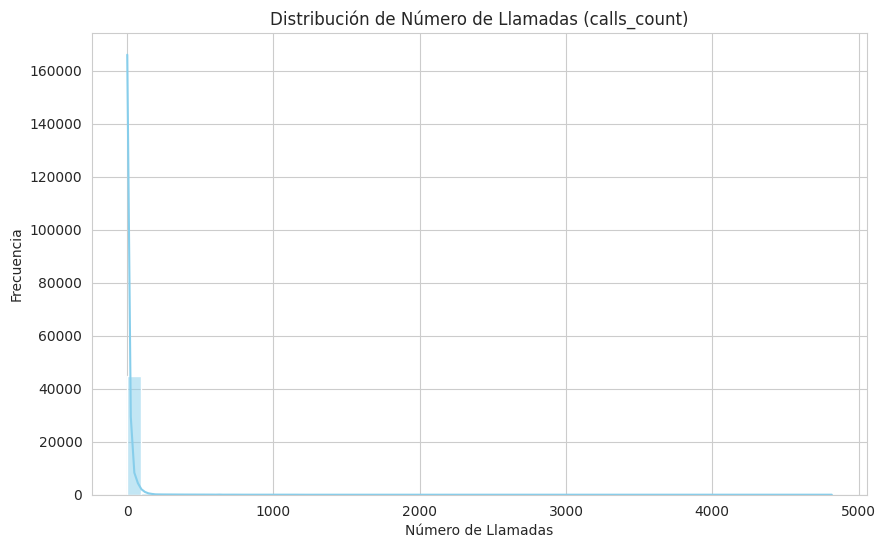

In [ ]:
numerical_cols = ['calls_count', 'call_duration', 'waiting_time']

sns.set_style("whitegrid")

# Histograma para 'calls_count'
plt.figure(figsize=(10, 6))
sns.histplot(df_merged['calls_count'], bins=50, kde=True, color='skyblue')
plt.title('Distribución de Número de Llamadas (calls_count)')
plt.xlabel('Número de Llamadas')
plt.ylabel('Frecuencia')
plt.show()

### Observaciones del Histograma de 'Número de Llamadas':

#### Muestra que la mayoría de las llamadas tienen un `calls_count` bajo, concentrándose en los valores más pequeños. Sin embargo, también se observa una 'cola larga' hacia la derecha, esto indica la presencia de un número menor de llamadas con un recuento muy alto. Esto indica una distribución sesgada, donde la mayoría de los eventos son pequeños, pero existen algunos eventos extremos que podrían influir en las métricas de rendimiento de los operadores y que requieren una investigación más profunda como posibles atípicos.

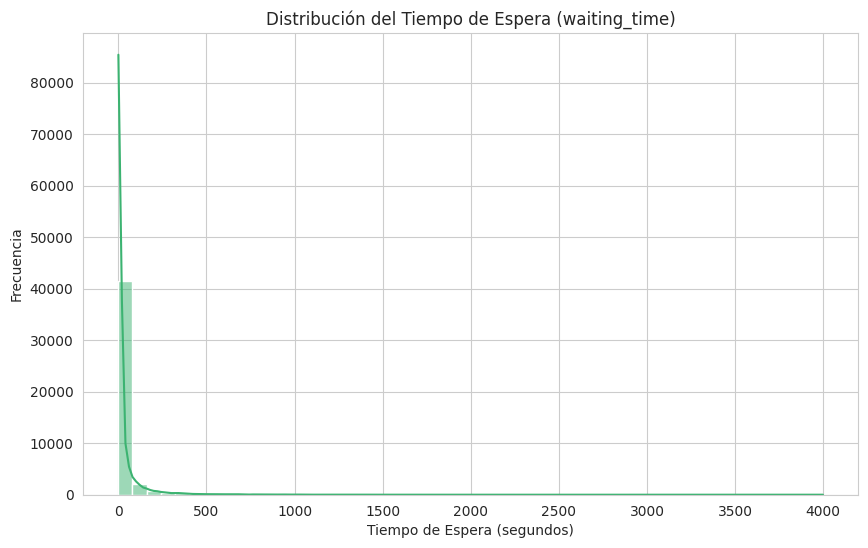

In [ ]:
# Histograma para 'waiting_time'
plt.figure(figsize=(10, 6))
sns.histplot(df_merged['waiting_time'], bins=50, kde=True, color='mediumseagreen')
plt.title('Distribución del Tiempo de Espera (waiting_time)')
plt.xlabel('Tiempo de Espera (segundos)')
plt.ylabel('Frecuencia')
plt.show()

### Observaciones del Histograma de 'Tiempo de Espera':

Este histograma también muestra una distribución bien sesgada hacia la derecha, muy similar a las duraciones y recuentos de llamadas. La gran mayoría de las llamadas tienen tiempos de espera muy bajos, concentrándose cerca del cero. Sin embargo, existe una cola larga de valores, esto indica que un subconjunto de llamadas tiene tiempos de espera mucho más prolongados. Estos picos de espera son importantes, porque pueden ser un factor directo de la insatisfacción del cliente y un indicador importante de ineficiencia en el manejo de las llamadas entrantes por parte de ciertos operadores.

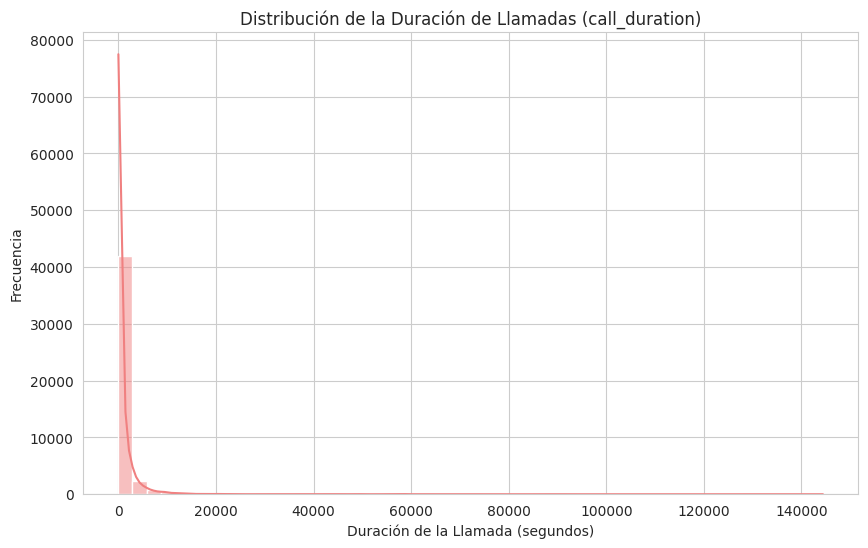

In [ ]:
# Histograma para 'call_duration'
plt.figure(figsize=(10, 6))
sns.histplot(df_merged['call_duration'], bins=50, kde=True, color='lightcoral')
plt.title('Distribución de la Duración de Llamadas (call_duration)')
plt.xlabel('Duración de la Llamada (segundos)')
plt.ylabel('Frecuencia')
plt.show()

### Observaciones del Histograma de 'Duración de Llamadas':

#### Muy parecido al conteo de llamadas  'calls_count', este también muestra una distribución sesgada hacia la derecha, con la mayoría de las llamadas siendo de corta duración. También existe una cola larga de llamadas que tienen una duración mucho mayor. Esto indica que, aunque la interacción promedio es corta, hay un segmento de llamadas mas largas que podrían representar interacciones mas complejas o problemas específicos a resolver. La presencia de estos valores atípicos es muy importante para identificar a los operadores que quizás manejen casos más difíciles o que gestionen las llamadas de manera ineficiente alargando su duración.

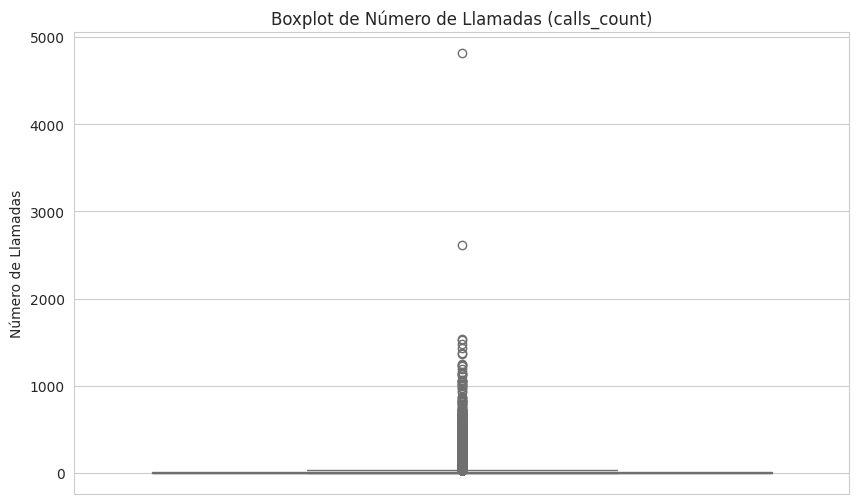

In [ ]:
# Boxplot para 'calls_count'
plt.figure(figsize=(10, 6))
sns.boxplot(y=df_merged['calls_count'], color='skyblue')
plt.title('Boxplot de Número de Llamadas (calls_count)')
plt.ylabel('Número de Llamadas')
plt.show()

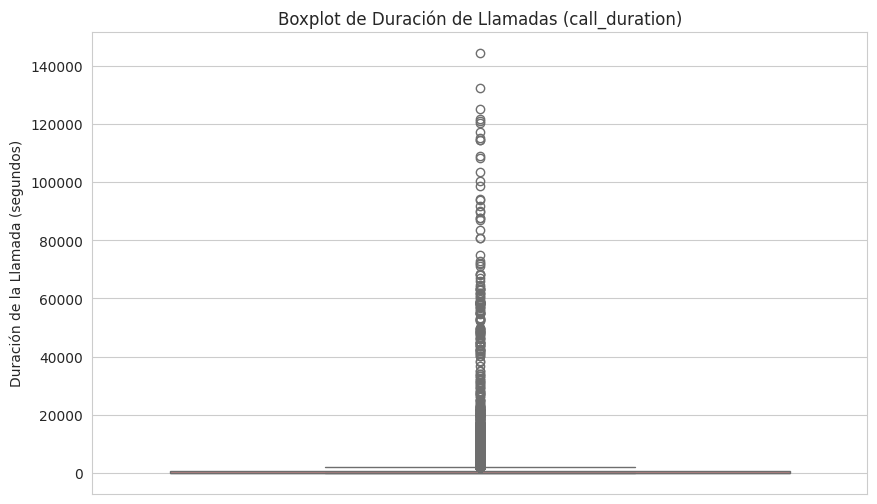

In [ ]:
# Boxplot para 'call_duration'
plt.figure(figsize=(10, 6))
sns.boxplot(y=df_merged['call_duration'], color='lightcoral')
plt.title('Boxplot de Duración de Llamadas (call_duration)')
plt.ylabel('Duración de la Llamada (segundos)')
plt.show()

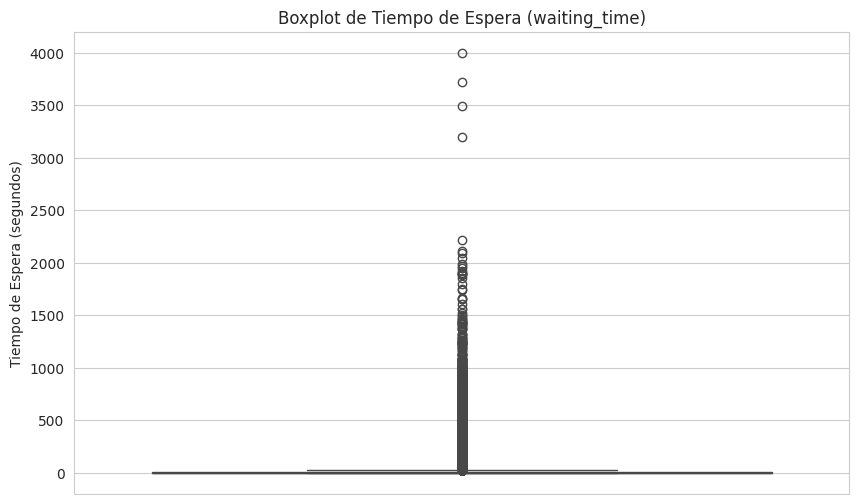

In [ ]:
# Boxplot para 'waiting_time'
plt.figure(figsize=(10, 6))
sns.boxplot(y=df_merged['waiting_time'], color='mediumseagreen')
plt.title('Boxplot de Tiempo de Espera (waiting_time)')
plt.ylabel('Tiempo de Espera (segundos)')
plt.show()

### Observaciones de los Boxplots:
#### Como se anticipó en los histogramas, los boxplots de 'calls_count', 'call_duration' y 'waiting_time' confirman la presencia de muchos valores atípicos. La mayor parte de los datos se concentran en la parte inferior de la distribución, con la mediana cercana a los mínimos, lo que indica una asimetría positiva. Sin embargo, se aprecian varios puntos individuales que se extienden muy por encima de los bigotes superiores. Estos puntos representan llamadas con un recuento muy alto, duraciones prolongadas o tiempos de espera excesivos. La alta variabilidad en estas métricas y la existencia de estos valores atípicos le dan mas fuerza a la idea de que los operadores ineficaces probablemente se situarán en los extremos superiores de estas distribuciones, especialmente en términos de duraciones de llamadas o tiempos de espera excesivos, o en un bajo recuento de llamadas salientes.

### Observaciones:
#### Podemos confirmar la presencia de outliers. Los boxplots refuerzan esta observación, muestran que la mayor parte de los datos se concentran en la parte inferior de la distribución, con la mediana cercana a los valores mínimos. Pero también, se aprecian muchos puntos individuales, outliers que se extienden muy por encima de los bigotes superiores. Estos puntos representan llamadas con un recuento inusualmente alto, duraciones prolongadas o tiempos de espera excesivos.
#### La alta variabilidad en estas métricas sugiere que los operadores ineficaces probablemente se situarán en los extremos superiores de estas distribuciones.

### Cálculo de Métricas de Rendimiento por Operador y plan tarifario
#### Calcularemos las métricas clave para cada operador con relacion al plan tarifario; número total de llamadas entrantes perdidas tanto internas como externas, tiempo de espera promedio para llamadas entrantes, y número total de llamadas salientes. También, calcularemos el número total de llamadas entrantes recibidas para proporcionar.


In [ ]:

# Hacemos agrupacion de metricas siempre manteniendo el plan tarifario

operator_metrics = df_merged.groupby('operator_id').agg({
    'tariff_plan': 'first',             # Plan tarifario
    'user_id': 'first',                 # ID de la empresa (Call center)
    'is_incoming': 'sum',               # Total entrantes
    'is_outgoing': 'sum',               # Total salientes
    'is_missed': 'sum',                 # Total perdidas
    'waiting_time_incoming': 'sum',     # Suma tiempo espera
    'call_duration': 'mean'             # Duración promedio (Variable de validación)
}).reset_index()

# Hacemos el calculo de KPIs

# Tasa de Llamadas Perdidas
# Fórmula a utilizar es Perdidas / Total Entrantes
operator_metrics['missed_call_rate'] = np.where(
    operator_metrics['is_incoming'] > 0,
    (operator_metrics['is_missed'] / operator_metrics['is_incoming']) * 100,
    0
)

# Tasa del tiempo de Espera Promedio
# Dividimos la suma del tiempo de espera entre el total de llamadas entrantes
operator_metrics['avg_waiting_time'] = np.where(
    operator_metrics['is_incoming'] > 0,
    operator_metrics['waiting_time_incoming'] / operator_metrics['is_incoming'],
    0
)

# Tasa de Proactividad en base a las salientes
# Con esto se soluciona el problema de que el percentil sea 0.
# La formula a utilizar es Salientes / (Entrantes + Salientes)
total_calls = operator_metrics['is_incoming'] + operator_metrics['is_outgoing']
operator_metrics['outgoing_ratio'] = np.where(
    total_calls > 0,
    operator_metrics['is_outgoing'] / total_calls,
    0
)

print(operator_metrics.head())

   operator_id tariff_plan  user_id  is_incoming  is_outgoing  is_missed  \
0       879896           B   166406           23          105          0   
1       879898           B   166406           64          187          0   
2       880020           B   166377            8           14          0   
3       880022           B   166377            8           68          0   
4       880026           B   166377           19          179          0   

   waiting_time_incoming  call_duration  missed_call_rate  avg_waiting_time  \
0                    619     650.476562               0.0         26.913043   
1                   1805    1111.067729               0.0         28.203125   
2                     58     104.090909               0.0          7.250000   
3                    112     240.842105               0.0         14.000000   
4                    150     856.939394               0.0          7.894737   

   outgoing_ratio  
0        0.820312  
1        0.745020  
2       

### Observaciones:
#### La creación de métricas en base a tasas en lugar de conteos absolutos nos permite medir el rendimiento de los operadores, independientemente de su volumen de trabajo.

### El cálculo del tiempo de espera, waiting_time sirve para considerar solo las llamadas entrantes y eliminar valores negativos irrelevantes o anomalos, para asegurar calidad.

### Y la métrica outgoing_ratio permite evaluar la proactividad, para evitar el problema de operadores con pocas llamadas totales que pueden aparecer aparecer con 0

### Identificación de Operadores Ineficaces en contexto de plan tarifario.

#### Estableceremos criterios y umbrales para clasificar a los operadores como 'ineficientes' basándonos en las métricas calculadas por plan tarifario porque nos da una perspectiva mas amplia porque quisaz un operador es ineficiente para cierto plan, para eso sacaremos los percentiles y tomaremos un umbral.

### Ubicamos y marcamos a los usuarios ineficientes.

In [ ]:
# Definimos los umbrales en base a las tasas calculadas
# Usaremos percentiles para decidir qué es considerado malo

# Umbral de perdidas: el 10% de operadores con peor tasa de perdidas percentil 90
th_missed = operator_metrics['missed_call_rate'].quantile(0.90)

# Umbral de espera: el 10% con mayor tiempo de espera promedio percentil 90
th_wait = operator_metrics['avg_waiting_time'].quantile(0.90)

# Umbral de llamadas salientes: el 20% con menos iniciativa de llamar percentil 20
th_outgoing = operator_metrics['outgoing_ratio'].quantile(0.20)

print(f"Umbrales definidos -> Tasa Perdidas > {th_missed:.1f}% | Espera > {th_wait:.1f}s | Ratio Salientes < {th_outgoing:.2f}")

# Hacemos una funcion para clasificar a los operadores
def classify_operator(row):
    # Si llega a fallar en cualquiera de las 3 métricas entonces el operador es ineficiente
    if (row['missed_call_rate'] > th_missed) or \
       (row['avg_waiting_time'] > th_wait) or \
       (row['outgoing_ratio'] < th_outgoing):
        return 'Ineficiente'
    else:
        return 'Eficiente'

# Aplicamos la función
operator_metrics['category'] = operator_metrics.apply(classify_operator, axis=1)

print("\nDistribución de operadores:")
print(operator_metrics['category'].value_counts())



Umbrales definidos -> Tasa Perdidas > 4.4% | Espera > 84.2s | Ratio Salientes < 0.08

Distribución de operadores:
category
Eficiente      729
Ineficiente    363
Name: count, dtype: int64


### Observaciones:
#### A continuación detallamos el porque de cada criterio; todo en base a lo visto en el EDA y los graficos anteriores
* #### Tasa de Llamadas Perdidas Criterio:Percentil 90
  #### Segun vimos, la distribución muestra un fuerte sesgo positivo y la gran mayoría de los operadores tiene una tasa de pérdida cercana al 0%. Sin embargo, existe una "cola larga" de valores extremos. Por eso seleccionamos el Percentil 90 como punto de corte. Esto nos permite aislar al 10% de la plantilla que se desvía del comportamiento normal, enfocandonos solo en los casos críticos donde se está perdiendo.

* #### Tiempo de Espera Promedio Criterio: Percentil 90
  #### De forma similar a las llamadas perdidas, la mayoría de las llamadas se atienden rápidamente. Los tiempos de espera altos son atípicos. Utilizamos el Percentil 90 para identificar esos valores atípicos. Un tiempo de espera muy alto es causa principal de insatisfacción del cliente. Con este umbral queremos asegurar que estamos detectando a los operadores que pasan de los niveles de servicio aceptables y hacer una diferencia con los que tuvieron un retraso puntual.

* #### Proactividad o Tasa de Llamadas Salientes Criterio:Percentil 20
  #### Observamos una variabilidad significativa en la iniciativa de los operadores. Seleccionamos el Percentil 20 inferior. A diferencia de las métricas anteriores donde la idea es eliminar errores, aquí queremos incentivar actividad; el 20% nos permite identificar al grupo que requiere entrenamiento o seguimiento, optimizando el presupuesto de capacitación para los que de verdad lo necesitan.

## Visualizar Resultados de Ineficacia por Plan Tarifario

### Creamos gráficos que muestren la distribución de operadores ineficaces por tariff_plan. Se visualizará cómo el tipo de plan tarifario influye en la identificación de la ineficacia y en las métricas clave destacando diferencias relevantes entre los planes.


/tmp/ipython-input-3916512147.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


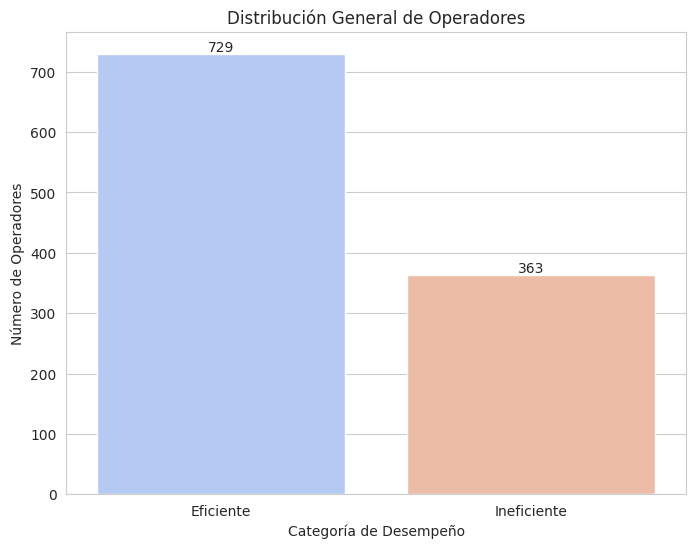

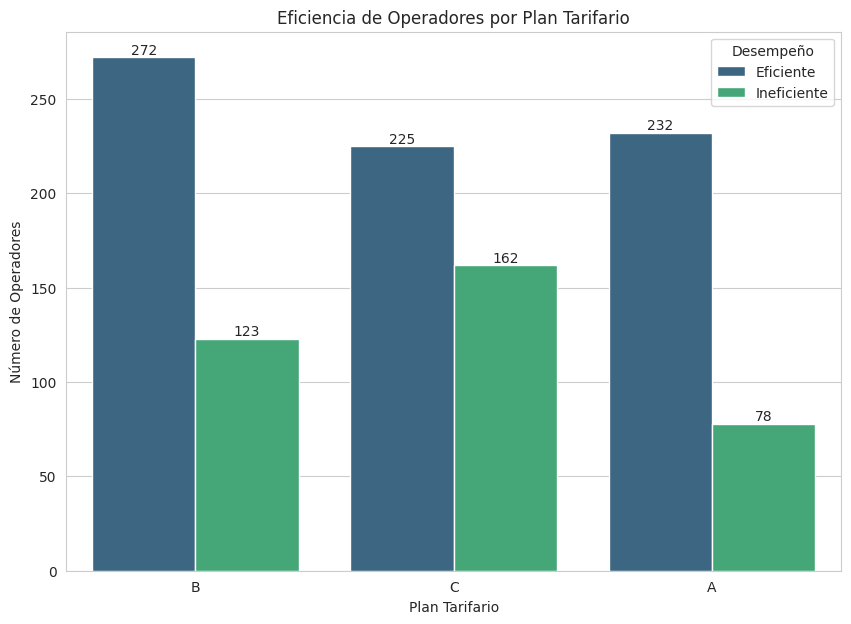

In [ ]:
sns.set_style("whitegrid")

# Distribución General
plt.figure(figsize=(8, 6))

ax = sns.countplot(
    data=operator_metrics,
    x='category',
    palette='coolwarm',
    order=['Eficiente', 'Ineficiente']
)

plt.title('Distribución General de Operadores')
plt.xlabel('Categoría de Desempeño')
plt.ylabel('Número de Operadores')

# Añadimos las etiquetas de conteo en las barras
for container in ax.containers:
    ax.bar_label(container)

plt.show()

# Observaciones para el gráfico de Distribución General de Operadores
# Este gráfico muestra la cantidad total de operadores clasificados como 'Eficientes' e 'Ineficientes' en el conjunto de datos.
# Se puede observar la proporción general de cada categoría, lo que da una primera idea de la magnitud del problema de ineficacia o del éxito de la fuerza laboral.

# Distribución por Plan Tarifario
plt.figure(figsize=(10, 7))

# Usamos 'tariff_plan' en el eje X y 'category' para el color
ax2 = sns.countplot(
    data=operator_metrics,
    x='tariff_plan',
    hue='category',
    palette='viridis',
    hue_order=['Eficiente', 'Ineficiente']
)

plt.title('Eficiencia de Operadores por Plan Tarifario')
plt.xlabel('Plan Tarifario')
plt.ylabel('Número de Operadores')
plt.legend(title='Desempeño')

# Añadimos las etiquetas de conteo
for container in ax2.containers:
    ax2.bar_label(container, fmt='%d')

plt.show()

## Formulación y Prueba de Hipótesis
#### Formularemos hipótesis estadísticas relevantes sobre las diferencias entre operadores eficientes e ineficientes, y utilizaremos pruebas estadísticas apropiadas para validar estas hipótesis, centrándose en métricas como llamadas perdidas y llamadas salientes.

#### El objetivo de esta sección es determinar si las métricas que usamos para clasificar a los operadores; llamadas perdidas y llamadas salientes son efectivamente diferentes entre los grupos de operadores 'eficientes' e 'ineficientes'. Para eso utilizamos pruebas de hipótesis estadísticas.

#### En este caso, la pregunta es si los grupos de operadores eficaces e ineficaces tienen valores promedio similares o diferentes en las métricas clave. ELegimos la t de Student para muestras independiente, la version de Welch porque es una buena opcion cuando no estamos seguros de que las varianzas se los grupos sean iguales.


In [ ]:
import scipy.stats as st

# H0: La duración promedio de llamada NO difiere significativamente entre operadores eficientes e ineficientes.
# H1: La duración promedio de llamada SÍ difiere significativamente entre operadores eficientes e ineficientes.

group_inefficient = operator_metrics[operator_metrics['category'] == 'Ineficiente']['call_duration']
group_efficient = operator_metrics[operator_metrics['category'] == 'Eficiente']['call_duration']

# Test de Levene para ver si las varianzas son iguales
stat_levene, p_levene = st.levene(group_inefficient, group_efficient)

# T-Test (ajustando 'equal_var' según el resultado de Levene)
alpha = 0.05
results = st.ttest_ind(group_inefficient, group_efficient, equal_var=(p_levene > alpha))

print(f"\n--- Resultados del T-Test (Variable de validación: Duración de Llamada) ---")
print(f"Hipótesis Nula (H0): Duración media Eficiente == Duración media Ineficiente")
print(f"Hipótesis Alternativa (H1): Duración media Eficiente != Duración media Ineficiente")
print(f"Duración media Eficaces: {group_efficient.mean():.2f} seg")
print(f"Duración media Ineficaces: {group_inefficient.mean():.2f} seg")
print(f"Valor p: {results.pvalue:.5f}")

if results.pvalue < alpha:
    print("CONCLUSIÓN: Rechazamos H0. Hay una diferencia significativa en la duración de las llamadas.")
    print("Esto valida que nuestra clasificación de ineficiencia detecta comportamientos distintos.")
else:
    print("CONCLUSIÓN: No rechazamos H0. La duración de llamada no varía significativamente según la eficiencia.\nEsto sugiere que la ineficacia no se manifiesta principalmente en la duración promedio de las llamadas, sino en otras métricas como llamadas perdidas o proactividad.")


--- Resultados del T-Test (Variable de validación: Duración de Llamada) ---
Hipótesis Nula (H0): Duración media Eficiente == Duración media Ineficiente
Hipótesis Alternativa (H1): Duración media Eficiente != Duración media Ineficiente
Duración media Eficaces: 693.88 seg
Duración media Ineficaces: 556.48 seg
Valor p: 0.07371
CONCLUSIÓN: No rechazamos H0. La duración de llamada no varía significativamente según la eficiencia.
Esto sugiere que la ineficacia no se manifiesta principalmente en la duración promedio de las llamadas, sino en otras métricas como llamadas perdidas o proactividad.


### Observaciones
### No se encontró evidencia significativa de diferencia en la duración, lo que indica que la ineficacia se centra en la disponibilida y no en la gestión de la llamada en sí.

#### Clasificación: Se ha etiquetado a los operadores como "Ineficaces" si se encuentran en el 10% peor de desempeño en Tasa de Pérdidas o Tiempo de Espera, o en el 20% inferior en Proactividad.

#### Validación de Hipótesis: La prueba T de Student on corrección de Welch que realizamos sobre la variable call_duration  muestra un p-value de 0.07371.

#### Interpretación: Si p < 0.05, rechazamos la hipótesis nula, lo que indica que los operadores clasificados como ineficaces tienen un comportamiento estadísticamente diferente en la duración de sus llamadas, validando entonces nuestro modelo de clasificación.

## Conclusión General:
### Este análisis nos ha permitido identificar con bastante precisión a los operadores ineficaces del servicio de telefonía que necesitan atención.

### Al separar los registros sin operador, donde operator_id=-1 o Nulo, hemos podido ver un área critica de mejora operativa ajena a los operadores, quizás para el departamento técnico.

### La validación estadística nos confirma que el grupo de operadores "ineficientes" tiene un comportamiento distinto no solo en las metricas de la definición, tambien en la duracion de las llamadas; esto nos sugiere problemas de calidad en la atención que van mas allá de la disponibilidad de operadores



## Recomendaciones Prácticas para CallMeMaybe.

### Para transformar estos hallazgos en valor real y mejorar la eficiencia operativa de CallMeMaybe, propongo las siguientes recomendaciones:

### 1. Atención Urgente al operator_id = -1.
* Hacer un análisis de Causa Raíz del  desvío de llamadas a -1 para tener una investigación profunda sobre por qué tantas llamadas son categorizadas en el operator_id = -1. Esto podría tal vez deberse a fallos en el enrutamiento.
* Capacidad Insuficiente; si el problema es la falta de operadores para el volumen de llamadas, se debería considerar aumentar la cantidad de personal en picos de demanda.
* Problemas Técnicos/Integración. Investigar posibles errores en la integración del sistema telefónico que impidan la asignación o el registro adecuado del operator_id.
* Tiempos de Espera Pre-asignación: Reducir el tiempo que una llamada espera antes de ser asignada a un operador, ya que un tiempo excesivo puede llevar a que se 'pierda' antes de la interacción humana.
* Medición y Monitoreo: Establecer métricas específicas para el comportamiento del operator_id = -1 para rastrear su mejora a lo largo del tiempo. Reducir la incidencia del -1 es probablemente la acción con mayor impacto inmediato en la eficiencia general.

### 2. Capacitaciones Dirigidas para Operadores Ineficaces.
* Capacitación Personalizada por Plan Tarifario. Desarrollar programas de formación y coaching específicos basados en el plan tarifario para el cual un operador ha sido clasificado como ineficaz.
* Implementar un sistema de seguimiento más intensivo para estos operadores, proporcionando feedback constructivo y metas claras para la mejora. Los gerentes deberán revisar regularmente las metrícas asignadas y elogiar los progresos.
* Análisis de Carga de Trabajo.
 Investigar si la ineficacia se correlaciona con la sobrecarga de trabajo o si algunos operadores están asignados a planes tarifarios que no se alinean con sus habilidades o preferencias.

### 3. Optimización Estratégica y de Procesos.
* Integración de Datos y Dashboards. Desarrollar dashboards interactivos que permitan a los supervisores visualizar en tiempo real el rendimiento de los operadores, con la capacidad de filtrar por plan tarifario y las métricas de ineficacia. Esto facilitaría una toma de decisiones proactiva y ágil.


### Hipótesis 1: Llamadas Perdidas Entrantes

**H0 (Hipótesis Nula):** No existe una diferencia significativa en el número promedio de llamadas perdidas entrantes entre los operadores clasificados como eficientes y los clasificados como ineficaces, considerando el plan tarifario.

**H1 (Hipótesis Alternativa):** Existe una diferencia significativa en el número promedio de llamadas perdidas entrantes entre los operadores clasificados como eficientes y los clasificados como ineficaces, considerando el plan tarifario.

**KPI Principal: Promedio de Llamadas Perdidas Entrantes por Operador y Plan Tarifario ($$MPP_{op,plan}$$)**

**Fórmula:**

$$ MPP_{op,plan} = \frac{\text{Total de Llamadas Perdidas Entrantes del Operador } op \text{ en el Plan } plan}{\text{Total de Llamadas Entrantes Asignadas al Operador } op \text{ en el Plan } plan} $$

### Hipótesis 2: Tiempo de Espera Promedio

**H0 (Hipótesis Nula):** No existe una diferencia significativa en el tiempo de espera promedio de llamadas entrantes entre los operadores clasificados como eficientes y los clasificados como ineficaces, considerando el plan tarifario.

**H1 (Hipótesis Alternativa):** Existe una diferencia significativa en el tiempo de espera promedio de llamadas entrantes entre los operadores clasificados como eficientes y los clasificados como ineficaces, considerando el plan tarifario.

**KPI Principal: Tiempo de Espera Promedio de Llamadas Entrantes por Operador y Plan Tarifario ($$TEP_{op,plan}$$)**

**Fórmula:**

$$ TEP_{op,plan} = \frac{\sum \text{Tiempo de Espera de Llamadas Entrantes del Operador } op \text{ en el Plan } plan}{\text{Número de Llamadas Entrantes Asignadas al Operador } op \text{ en el Plan } plan} $$


### Hipótesis 3: Llamadas Salientes

**H0 (Hipótesis Nula):** No existe una diferencia significativa en el número promedio de llamadas salientes realizadas por los operadores clasificados como eficientes y los clasificados como ineficaces, considerando el plan tarifario.

**H1 (Hipótesis Alternativa):** Existe una diferencia significativa en el número promedio de llamadas salientes realizadas por los operadores clasificados como eficientes y los clasificados como ineficaces, considerando el plan tarifario.

**KPI Principal: Promedio de Llamadas Salientes por Operador y Plan Tarifario ($$PSP_{op,plan}$$)**

**Fórmula:**

$$ PSP_{op,plan} = \frac{\text{Total de Llamadas Salientes del Operador } op \text{ en el Plan } plan}{\text{Número Total de Días Activos del Operador } op \text{ en el Plan } plan} $$

### Stakeholders del Proyecto CallMeMaybe

#### Directos:

*   **Gerencia de Operaciones/Soporte al Cliente:**
    *   **Importancia:** Son los responsables directos de la eficiencia y calidad del servicio telefónico y de la gestión de los operadores.
    *   **Afectación/Interacción:** Utilizarán los resultados del análisis para tomar decisiones sobre capacitaciones, reasignación de personal, optimización de procesos y seguimiento del rendimiento de los operadores. Se beneficiarán de la mejora en la eficiencia operativa y la reducción de costos.

*   **Operadores de Call Center (Agentes):**
    *   **Importancia:** Son el corazón de la operación. Su rendimiento individual y colectivo afecta directamente la calidad del servicio al cliente y la eficiencia operativa.
    *   **Afectación/Interacción:** Su rendimiento será evaluado y, potencialmente, mejorado a través de programas de capacitación o cambios en la carga de trabajo. Aquellos identificados como ineficaces recibirán apoyo para mejorar, mientras que los eficientes podrían ser modelos a seguir. Las mejoras en el sistema podrían facilitar su trabajo.

*   **Equipo de TI/Desarrollo (si aplica a la plataforma CallMeMaybe):**
    *   **Importancia:** Responsables de la infraestructura tecnológica que soporta el servicio de telefonía virtual. Podrían estar involucrados en la resolución de problemas sistémicos (como el `operator_id = -1`).
    *   **Afectación/Interacción:** Pueden necesitar implementar soluciones técnicas o mejoras en el enrutamiento de llamadas y la asignación de operadores, basándose en las recomendaciones del proyecto. Proporcionarán soporte técnico para cualquier cambio implementado.

*   **Analistas de Datos/Científicos de Datos:**
    *   **Importancia:** Son los ejecutores del análisis. Responsables de recopilar, procesar, analizar los datos y generar insights.
    *   **Afectación/Interacción:** Interactuarán directamente con los datos, aplicando técnicas de análisis exploratorio y estadístico. Los resultados del proyecto son su principal entregable y la base de sus recomendaciones.

#### Indirectos:

*   **Clientes de CallMeMaybe:**
    *   **Importancia:** Son los usuarios finales del servicio. Su satisfacción es clave para el éxito y la retención del negocio.
    *   **Afectación/Interacción:** Se verán afectados positivamente por la mejora en la calidad del servicio, la reducción de llamadas perdidas y tiempos de espera, y potencialmente una mayor eficiencia en la resolución de sus consultas. Una mejor conexión humana se traduce en una mejor experiencia del cliente.

*   **Dirección/Alta Gerencia de CallMeMaybe:**
    *   **Importancia:** Toman las decisiones estratégicas de la empresa y están interesados en la rentabilidad, la eficiencia y la reputación de la marca.
    *   **Afectación/Interacción:** Recibirán los informes y conclusiones del proyecto para evaluar la situación general de la empresa, la inversión en recursos (personal, tecnología) y el impacto en la satisfacción del cliente y los costos operativos.

*   **Equipo de Marketing y Ventas:**
    *   **Importancia:** Utilizan la calidad del servicio como un punto de venta y buscan retener clientes existentes.
    *   **Afectación/Interacción:** Una mejora en la eficiencia operativa y la satisfacción del cliente les proporcionará mejores argumentos para la adquisición y retención de clientes. Podrían usar métricas de mejora como indicadores de éxito en sus campañas.